In [1]:
from utils.motif import init_repro

init_repro(42, deterministic=True)

import sys
import os
sys.path.append(os.path.abspath("./utils"))

from utils.explanations import (
    render_explained_video_small_tl,
    explain_instance,
    plot_attention_heatmaps,
    print_explanation_with_labels,
)
import matplotlib.pyplot as plt

import pickle
import io

import clip
import torch

# Helper function to load pickle files on CPU-only devices
def load_pickle_cpu(file_path):
    """Load a pickle file, mapping all CUDA tensors to CPU."""
    # Temporarily patch torch's default_restore_location to map CUDA to CPU
    original_restore = torch.serialization.default_restore_location
    
    def cpu_restore_location(storage, location):
        # Map any CUDA device to CPU (handle both string and torch.device)
        if isinstance(location, str) and location.startswith('cuda'):
            location = 'cpu'
        elif isinstance(location, torch.device) and location.type == 'cuda':
            location = torch.device('cpu')
        return original_restore(storage, location)
    
    # Apply the patch
    torch.serialization.default_restore_location = cpu_restore_location
    
    try:
        with open(file_path, "rb") as f:
            obj = pickle.load(f)
        return obj
    finally:
        # Restore original function
        torch.serialization.default_restore_location = original_restore

## Loading of MoTIF Checkpoint

In [2]:
dataset = "breakfast"

clip_model = "pe-l14"  # res50, b16, b32, l14, siglip, clip4clip

if dataset == "breakfast":
    dataset_name = "Breakfast"
elif dataset == "ucf101":
    dataset_name = "UCF101"
elif dataset == "hmdb51":
    dataset_name = "HMDB"
elif dataset == "something2":
    dataset_name = "Something2"
else:
    print(f"{dataset} not found")

model_name = f"./Models/checkpoint_{clip_model}_{dataset_name}.pkl"

if os.path.exists(model_name):
    try:
        # Use CPU-compatible loading for CPU-only devices
        cbm_model = load_pickle_cpu(model_name)
        # Ensure model and all tensors are on CPU
        if hasattr(cbm_model, 'model') and cbm_model.model is not None:
            cbm_model.model = cbm_model.model.cpu()
        if hasattr(cbm_model, 'device'):
            cbm_model.device = torch.device('cpu')
        print("Loaded existing MoTIF model from", model_name)
    except FileNotFoundError:
        print("MoTIF file not found, creating a new one.")
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Trying alternative loading method...")
        # Fallback: try with torch.load if it's a torch checkpoint
        try:
            import torch
            cbm_model = torch.load(model_name, map_location='cpu', weights_only=False)
            if hasattr(cbm_model, 'model') and cbm_model.model is not None:
                cbm_model.model = cbm_model.model.cpu()
            if hasattr(cbm_model, 'device'):
                cbm_model.device = torch.device('cpu')
            print("Loaded existing MoTIF model from", model_name, "(using torch.load)")
        except Exception as e2:
            print(f"Failed to load model: {e2}")
            raise

Loaded existing MoTIF model from ./Models/checkpoint_pe-l14_Breakfast.pkl


## Print Global and Local top-k Explanations

In [3]:
# Build once from your training cell
label_decoder = cbm_model.encoder  # the fitted LabelEncoder

# Pick an example
i = 500 # define a number in the test set
video = cbm_model.X_test[i] # you can also switch to the train set
true_idx = cbm_model.y_test[i]
vid_path = cbm_model.paths_test[i]

# Explain
res = explain_instance(cbm_model.model, video)
print_explanation_with_labels(
    res,
    cbm_model.video_spans[vid_path],
    label_decoder=label_decoder,
    true_label_idx=true_idx,
    concepts_list=cbm_model.concepts.text_concepts,
    top_k_times=5, # how many local concept windows
    top_k_concepts=4, # how many top-k concepts per window
)

Predicted: 4 (milk) | True: 4 (milk)
Target class: 4

Top concepts (global):
  stir                           +1.382  ████████████████████
  scrub                          +1.086  ████████████████····
  measuringcup                   +0.906  █████████████·······
  juice                          +0.709  ██████████··········

Important time steps:
  t=[00:42.67 - 00:44.73] time_importance=0.254  TI[████████████████████]  Score[████████████████████]
     - stir                           +1.505  ████████████████████
     - scrub                          +1.222  ████████████████····
     - measuringcup                   +0.997  █████████████·······
     - sugar                          +0.734  ██████████··········
  t=[00:44.80 - 00:46.87] time_importance=0.245  TI[███████████████████·]  Score[████████████████████]
     - stir                           +1.689  ████████████████████
     - scrub                          +1.123  █████████████·······
     - measuringcup                   +1.041

## Temporal Dependency Plot

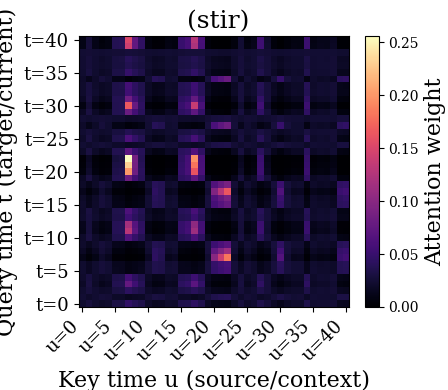

[<Figure size 500x400 with 2 Axes>]

In [4]:
def get_id(list, text):
    for i, item in enumerate(list):
        if item == text:
            return i
    print("Concept not included!")
    return 0


concept_idx = get_id(
    cbm_model.concepts.text_concepts, "stir"
)  # change concept name to find index in concept set

plot_attention_heatmaps(
    res,
    concept_idx=concept_idx,
    concept_names=cbm_model.concepts.text_concepts,
    layer_agg="mean",
    show_seconds=True,
    savepath=None,
)

## (Optional) Save Video

**Important**: This only works if you have correctly defined all paths and saved the videos as mp4 in the Dataset folder. Please follow our instructions.

In [6]:
video = cbm_model.X_test[i] 
true_idx = cbm_model.y_test[i]
vid_path = cbm_model.paths_test[i].replace("../", "./")

if os.path.exists(vid_path):
    # Explain (same as your code)
    res = explain_instance(cbm_model.model, video)
    out_mp4 = render_explained_video_small_tl(
        vid_path=vid_path,
        out_path=f"./Videos/{dataset}_{i}.mp4",
        res=res,
        fps_frame_seconds=cbm_model.video_spans[vid_path],
        label_decoder=label_decoder,
        true_label_idx=true_idx,
        concepts_list=cbm_model.concepts.text_concepts,
        up_scale=2.0,  # 2x upscaling
        top_k_times=0,  
        top_k_concepts=5,
    )
    print("Wrote:", out_mp4)
else:
    print("Video path does not exist:", vid_path)

Video path does not exist: ./Datasets/Breakfast/Video_data/P51/webcam02/P51_milk.mp4
